# Rescue Contrast and Cell-State Deep Dives

> **Where this fits:** NB8 established the obesity signal (SH vs SC) and the exercise signal
> (TC vs SC) in vWAT using pseudobulk DESeq2. This notebook asks the therapeutic question:
> does exercise training reverse what obesity did at the cell-type level? Then it digs into
> the three cell states where the most interesting biology lives.

## The rescue question

The paper's central therapeutic claim isn't just "exercise is good." It's specifically that
exercise *undoes* the molecular damage caused by obesity at the level of individual cell types.
The key contrast is:

- **TH** = high-fat diet + exercise training — obese animals that exercised
- **SH** = high-fat diet + sedentary — obese animals that did not exercise

TH vs SH directly measures: *of everything obesity dysregulated, how much does exercise put back?*

A gene upregulated by obesity (positive in SH vs SC) that is then suppressed by exercise in the
obese background (negative in TH vs SH) is **rescued**. The paper reports that 94–95% of adipose
bulk RNA-seq DEGs show this reversal pattern — a remarkably high fraction suggesting exercise is
a near-complete transcriptional antidote to obesity's effects in fat tissue.

**Why this contrast is harder to see:** Obesity vs baseline (SH vs SC) compares two stable states.
Rescue (TH vs SH) compares animals undergoing active metabolic recovery against a worsening
baseline — the signal is real biology, but it requires the experiment to have worked.

## What we cover

| Section | Cell state | Question |
|---------|------------|----------|
| 1. Rescue contrast | All states → WAT_IPC focus | How much of the obesity program does exercise reverse? |
| 2. Areg exercise | Areg | Why does Areg have *more* exercise DEGs than WAT_IPC? What is the Fndc5 signal? |
| 3. CP obesity | CP | 413 obesity DEGs vs IPC's 125 — same story or a different one? |
| 4. CP exercise | CP | Dgat2 (a fat-storage enzyme) goes *up* with exercise. Why? |

## Setup

Helper functions (`make_pseudobulks`, `run_deseq2`, `get_sig`) are carried over from NB8 verbatim.
They are redefined here because notebooks are self-contained — there is no import mechanism between
Jupyter notebooks.

This notebook **depends on NB8's output CSV**. The Areg and CP analyses load results that NB8
already computed rather than re-running DESeq2 for those contrasts. Run NB8 first.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse
from sklearn.decomposition import PCA

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('../GSE183288_Single_cell_atlas.h5ad')
OUT_DIR   = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

ECM_GENES       = ['Thbs1', 'Sparc', 'Col3a1', 'Col6a1', 'Col1a1', 'Col1a2']
CIRCADIAN_GENES = ['Dbp', 'Tef', 'Nr1d2', 'Per3', 'Hlf', 'Bmal1', 'Clock', 'Arntl']

PADJ_THRESH = 0.05
LFC_THRESH  = 0.5
MIN_CELLS   = 20

# Condition colors shared across all plots in this notebook
CONDITION_COLORS = {'SC': '#2166AC', 'TC': '#4DAF4A', 'SH': '#E41A1C', 'TH': '#FF7F00'}

In [ ]:
# ----- Helper functions (copied from NB8) -----

def make_pseudobulks(adata, cell_state, conditions,
                     cell_state_key='cell_state_label',
                     sample_key='sample_ID',
                     condition_key='intervention_group',
                     counts_layer='counts'):
    mask = (
        (adata.obs[cell_state_key] == cell_state) &
        (adata.obs[condition_key].isin(conditions))
    )
    sub = adata[mask]
    if sub.n_obs == 0:
        return None

    X = sub.layers[counts_layer]
    if issparse(X):
        X = X.toarray()

    df = pd.DataFrame(X, index=sub.obs_names, columns=sub.var_names)
    df[sample_key]    = sub.obs[sample_key].values
    df[condition_key] = sub.obs[condition_key].values
    gene_cols = sub.var_names.tolist()

    pb = df.groupby(sample_key).agg(
        {**{g: 'sum' for g in gene_cols}, condition_key: 'first'}
    )
    pb['n_cells'] = df.groupby(sample_key).size()
    pb = pb[pb['n_cells'] >= MIN_CELLS]

    if pb.empty:
        return None

    counts_df = pb[gene_cols].astype(int)
    meta_df   = pb[[condition_key, 'n_cells']].copy()

    counts_per_cond = meta_df[condition_key].value_counts()
    if counts_per_cond.min() < 2:
        return None

    return counts_df, meta_df


def run_deseq2(adata, cell_state, condition_a, condition_b,
               condition_key='intervention_group'):
    result = make_pseudobulks(adata, cell_state, [condition_a, condition_b])
    if result is None:
        return None

    counts_df, meta_df = result
    n_a = (meta_df[condition_key] == condition_a).sum()
    n_b = (meta_df[condition_key] == condition_b).sum()

    meta_df[condition_key] = pd.Categorical(
        meta_df[condition_key], categories=[condition_b, condition_a]
    )
    counts_df = counts_df.loc[:, counts_df.sum(axis=0) > 0]

    dds = DeseqDataSet(
        counts=counts_df,
        metadata=meta_df[[condition_key]],
        design=f'~{condition_key}',
        quiet=True,
    )
    dds.deseq2()

    stat_res = DeseqStats(
        dds,
        contrast=[condition_key, condition_a, condition_b],
        quiet=True,
    )
    stat_res.summary()

    df = stat_res.results_df.reset_index().rename(columns={
        'index': 'gene', 'log2FoldChange': 'log2FC', 'pvalue': 'pval',
    })
    df['n_a']        = n_a
    df['n_b']        = n_b
    df['contrast']   = f'{condition_a}_vs_{condition_b}'
    df['cell_state'] = cell_state
    return df


def get_sig(df, padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH):
    return df[
        df['padj'].notna() &
        (df['padj'] < padj_thresh) &
        (df['log2FC'].abs() > lfc_thresh)
    ].copy()


def per_mouse_counts(adata, gene, cell_state,
                     condition_key='intervention_group',
                     sample_key='sample_ID',
                     cell_state_key='cell_state_label',
                     counts_layer='counts'):
    """Sum raw counts for one gene across all cells per mouse, for one cell state."""
    sub = adata[adata.obs[cell_state_key] == cell_state]
    if gene not in sub.var_names:
        return None
    gene_idx = list(sub.var_names).index(gene)
    X = sub.layers[counts_layer]
    if issparse(X):
        X = X.toarray()
    col = X[:, gene_idx]
    tmp = pd.DataFrame({
        'count': col,
        sample_key: sub.obs[sample_key].values,
        condition_key: sub.obs[condition_key].values,
    })
    # observed=True suppresses phantom rows for Categorical columns.
    # Without it, pandas creates a zero-count row for every (sample_ID, condition)
    # combination in the Categorical levels even if that mouse isn't in this cell
    # state subset — making mice appear in conditions they don't belong to.
    return tmp.groupby([sample_key, condition_key], observed=True)['count'].sum().reset_index()


print('Helpers defined.')

In [3]:
adata = sc.read_h5ad(DATA_PATH)
print(f'Atlas: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

vwat = adata[adata.obs['tissue'] == 'vWAT'].copy()
print(f'vWAT:  {vwat.n_obs:,} cells')

# Confirm we have TH mice for the rescue contrast.
# The rescue contrast needs TH (trained + HFD) and SH (sedentary + HFD).
# N=3 TH and N=3 SH — same statistical power as the obesity contrast in NB8.
print('\nvWAT mice per condition:')
print(
    vwat.obs.groupby('intervention_group')['sample_ID']
    .nunique()
    .to_frame('n_mice')
)

Atlas: 204,883 cells x 17,341 genes
vWAT:  78,860 cells

vWAT mice per condition:
                    n_mice
intervention_group        
SC                       3
SH                       3
TC                       4
TH                       3


In [4]:
# Load NB8 full results — needed for Areg and CP deep dives (sections 2–4).
# The rescue contrast (section 1) is new and will be run fresh below.
NB8_FULL = OUT_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv'

if not NB8_FULL.exists():
    raise FileNotFoundError(
        f'NB8 output not found at {NB8_FULL}.\n'
        'Run 8_pseudobulk_differential_expression.ipynb first.'
    )

nb8 = pd.read_csv(NB8_FULL)
print(f'Loaded NB8 results: {len(nb8):,} rows')
print(f'Contrasts in NB8:   {nb8["contrast_label"].unique()}')
print(f'Cell states in NB8: {sorted(nb8["cell_state"].unique())}')

Loaded NB8 results: 435,439 rows
Contrasts in NB8:   ['obesity_SH_vs_SC' 'exercise_TC_vs_SC']
Cell states in NB8: ['Areg', 'B_Fo', 'CD4_Memory', 'CD4_Naive', 'CD8_Cytotoxic', 'CD8_Naive', 'CP', 'Fibroblast', 'Monocyte_Patrolling', 'NK', 'NKT', 'Tgd_CD27-', 'Treg', 'WAT_IPC', 'cDC1', 'cDC2', 'nILC2', 'pre_CP']


---

## Section 1: Rescue contrast (TH vs SH)

**The problem:** NB8 established that obesity (SH vs SC) upregulates ECM genes and downregulates
circadian genes in WAT_IPC cells. The exercise contrast (TC vs SC) partially restores circadian
genes. But those two contrasts don't directly answer the therapeutic question: *does exercise
counteract what obesity already did?*

**Why the rescue contrast is the paper's key claim:** The study design has four conditions arranged
in a 2x2 grid (diet x exercise). The obesity and exercise contrasts each move along one axis.
The rescue contrast moves along the exercise axis *starting from the obese state* — it directly
models the therapeutic intervention: an already-obese animal starts training.

**Interpreting direction:** Positive log2FC in TH vs SH means TH (exercise) > SH (no exercise).
- Circadian genes that obesity suppressed should be **positive** here (exercise restores them).
- ECM genes that obesity upregulated should be **negative** here (exercise reverses the buildup).

**The rescue fraction:** For every obesity DEG, we ask: does its sign flip in the rescue
contrast? Fraction that flip = rescue rate. The paper reports 94–95% at the bulk level.

In [5]:
vwat_states = sorted(vwat.obs['cell_state_label'].unique())
print(f'Running rescue contrast (TH vs SH) across {len(vwat_states)} vWAT cell states...\n')

rescue_results = {}

for state in vwat_states:
    # TH is condition_a (numerator) — positive log2FC = exercise raises this gene in obese background
    # SH is condition_b (reference) — the obese sedentary baseline
    res = run_deseq2(vwat, state, condition_a='TH', condition_b='SH')
    if res is None:
        print(f'  {state}: skipped (too few replicates)')
        continue
    sig = get_sig(res)
    rescue_results[state] = res
    print(f'  {state}: {res["n_a"].iloc[0]} TH vs {res["n_b"].iloc[0]} SH mice '
          f'-> {len(sig)} DEGs  '
          f'({(sig["log2FC"]>0).sum()} up with exercise, {(sig["log2FC"]<0).sum()} down)')

print(f'\nCell states successfully tested: {len(rescue_results)}')

Running rescue contrast (TH vs SH) across 35 vWAT cell states...

  Areg: 3 TH vs 3 SH mice -> 118 DEGs  (56 up with exercise, 62 down)
  B_Fo: 3 TH vs 2 SH mice -> 0 DEGs  (0 up with exercise, 0 down)
  CD4_Memory: 3 TH vs 2 SH mice -> 0 DEGs  (0 up with exercise, 0 down)
  CD4_Naive: 3 TH vs 2 SH mice -> 0 DEGs  (0 up with exercise, 0 down)
  CD8_Cytotoxic: 3 TH vs 2 SH mice -> 0 DEGs  (0 up with exercise, 0 down)
  CD8_Naive: 3 TH vs 2 SH mice -> 0 DEGs  (0 up with exercise, 0 down)
  CP: 3 TH vs 3 SH mice -> 244 DEGs  (122 up with exercise, 122 down)
  Capillary: skipped (too few replicates)
  Epi: skipped (too few replicates)
  Epididymis: skipped (too few replicates)
  Fibroblast: 3 TH vs 2 SH mice -> 23 DEGs  (7 up with exercise, 16 down)
  Large_artery: skipped (too few replicates)
  Large_vessel: skipped (too few replicates)
  Lymphatic: skipped (too few replicates)
  M1: 3 TH vs 2 SH mice -> 0 DEGs  (0 up with exercise, 0 down)
  M2: 3 TH vs 2 SH mice -> 6 DEGs  (4 up with ex

In [6]:
# WAT_IPC rescue: top genes, circadian restoration, ECM reversal

if 'WAT_IPC' not in rescue_results:
    print('WAT_IPC rescue results not available')
else:
    ipc_rescue     = rescue_results['WAT_IPC']
    ipc_rescue_sig = get_sig(ipc_rescue)

    print(f'WAT_IPC rescue DEGs (TH vs SH): {len(ipc_rescue_sig)} total')
    print(f'  Up with exercise:   {(ipc_rescue_sig["log2FC"] > 0).sum()}')
    print(f'  Down with exercise: {(ipc_rescue_sig["log2FC"] < 0).sum()}')

    print('\nTop 10 upregulated by exercise in obese background (restored):')
    print(
        ipc_rescue_sig[ipc_rescue_sig['log2FC'] > 0]
        .sort_values('log2FC', ascending=False)
        .head(10)[['gene', 'log2FC', 'padj']]
        .to_string(index=False)
    )

    print('\nTop 10 suppressed by exercise in obese background (inflammation/ECM reversed):')
    print(
        ipc_rescue_sig[ipc_rescue_sig['log2FC'] < 0]
        .sort_values('log2FC')
        .head(10)[['gene', 'log2FC', 'padj']]
        .to_string(index=False)
    )

    # Circadian genes: are the paper's key exercise genes restored in the rescue contrast?
    # These should be POSITIVE in TH vs SH if exercise reverses obesity's clock suppression.
    print('\nCircadian genes in rescue (paper\'s exercise story — should be positive):')
    circ_rescue = (
        ipc_rescue[ipc_rescue['gene'].isin(CIRCADIAN_GENES)]
        [['gene', 'log2FC', 'padj']]
        .sort_values('log2FC', ascending=False)
    )
    print(circ_rescue.to_string(index=False))

    # ECM genes: should be NEGATIVE in TH vs SH if exercise reverses obesity's ECM buildup.
    print('\nECM genes in rescue (obesity ECM story — should be negative):')
    ecm_rescue = (
        ipc_rescue[ipc_rescue['gene'].isin(ECM_GENES + ['Timp1'])]
        [['gene', 'log2FC', 'padj']]
        .sort_values('log2FC')
    )
    print(ecm_rescue.to_string(index=False))

WAT_IPC rescue DEGs (TH vs SH): 167 total
  Up with exercise:   89
  Down with exercise: 78

Top 10 upregulated by exercise in obese background (restored):
 gene   log2FC         padj
Gsto1 7.347596 2.582446e-02
Ptgfr 5.723997 4.868123e-04
  Hlf 5.025211 1.067107e-05
  Vtn 4.266355 1.224248e-02
  Dbp 4.084464 2.826810e-17
 Rbp4 3.900722 2.380986e-04
 Tnik 3.895233 1.592516e-03
Dgat2 3.722329 3.345627e-07
Il2ra 3.313980 5.470028e-04
Ciart 3.291001 2.044663e-02

Top 10 suppressed by exercise in obese background (inflammation/ECM reversed):
         gene    log2FC         padj
       Tmem98 -6.198253 1.534720e-04
       Gprin3 -4.501354 1.634231e-03
        Ccnb2 -4.372511 1.419608e-02
         Rin3 -3.597449 1.260394e-07
        Rsad2 -3.460889 2.674238e-02
         Fbn2 -3.361712 3.345627e-07
      Nectin2 -3.024225 9.754761e-03
C430049B03Rik -2.996882 3.022476e-05
         Cdk6 -2.963183 2.838973e-05
        Arntl -2.947789 6.186402e-13

Circadian genes in rescue (paper's exercise stor

### The Arntl/Bmal1 puzzle

Most circadian genes go **up** in the rescue contrast — exercise restores the clock in obese
fat stem cells. But Arntl (the gene that encodes Bmal1) goes **down**, despite being the
core positive transcriptional activator of the circadian clock.

This isn't necessarily wrong — it may reflect genuine clock phase resetting. The molecular
clock works as a feedback loop:

- **Positive arm (BMAL1/CLOCK):** activates transcription of *Per*, *Cry*, *Nr1d1/2*, *Dbp*, *Tef*
- **Negative arm (PER/CRY, Nr1d1/2):** represses BMAL1/CLOCK activity

The genes going *up* in the rescue contrast are mostly on the **repressive arm** (Nr1d2, Per3,
Dbp, Tef). Bmal1 going *down* is what you'd expect if the repressive arm is being activated —
it's not a broken clock, it's a clock changing phase.

**In obese sedentary animals (SH),** the clock is likely phase-disrupted or constitutively
expressed at a flat level (both arms dampened). **Exercise (TH)** may reinstate the normal
oscillation — raising the repressive arm (Nr1d2, Per3) *and* dampening the activating arm
(Bmal1) to restore the oscillatory pattern rather than simply turning everything up.

In [7]:
# Rescue fraction: of the obesity DEGs in WAT_IPC (from NB8), what fraction
# flip sign in the rescue contrast?
#
# This is the cell-state-level analog of the paper's bulk 94-95% rescue claim.
# We expect a different number because:
#   1. We're looking at one cell state (WAT_IPC) not all cell types averaged together
#   2. The paper's 94-95% is from bulk RNA-seq across scWAT, vWAT, SkM
#   3. N=3 vs 3 limits which obesity DEGs are in our set to begin with

if 'WAT_IPC' in rescue_results:
    # NB8 obesity DEGs for WAT_IPC
    # Filter: is_sig column was saved as bool; use thresholds directly to be safe
    ob_ipc = nb8[
        (nb8['cell_state'] == 'WAT_IPC') &
        (nb8['contrast_label'] == 'obesity_SH_vs_SC') &
        nb8['padj'].notna() &
        (nb8['padj'] < PADJ_THRESH) &
        (nb8['log2FC'].abs() > LFC_THRESH)
    ][['gene', 'log2FC']].copy()
    ob_ipc = ob_ipc.rename(columns={'log2FC': 'obesity_log2FC'})

    print(f'NB8 WAT_IPC obesity DEGs: {len(ob_ipc)}')

    # For each obesity DEG, look up whether the rescue contrast goes in the opposite direction.
    # We don't require significance in the rescue contrast — just sign flip.
    # This matches the paper's definition: sign reversal, not re-significance.
    rescue_lfc = ipc_rescue[['gene', 'log2FC', 'padj']].rename(
        columns={'log2FC': 'rescue_log2FC', 'padj': 'rescue_padj'}
    )

    merged = ob_ipc.merge(rescue_lfc, on='gene', how='inner')
    print(f'Genes testable in both contrasts: {len(merged)}')

    # Rescued = sign flips (obesity up → rescue down, or obesity down → rescue up)
    # np.sign() returns +1, 0, or -1; != means signs differ
    merged['is_rescued'] = np.sign(merged['obesity_log2FC']) != np.sign(merged['rescue_log2FC'])

    rescue_frac = merged['is_rescued'].sum() / len(merged) * 100
    print(f'\nRescue fraction (sign flip): {merged["is_rescued"].sum()}/{len(merged)} = {rescue_frac:.1f}%')
    print(f'Paper\'s bulk-level claim: 94-95%')
    print(f'\nNote: cell-state level analysis may differ from bulk because:')
    print(f'  - We are looking at WAT_IPC only, not averaging across all cell types')
    print(f'  - Bulk 94-95% includes scWAT, vWAT, and SkM together')
    print(f'  - Our obesity DEG set is conservative (N=3, strict thresholds)')

NB8 WAT_IPC obesity DEGs: 125
Genes testable in both contrasts: 125

Rescue fraction (sign flip): 121/125 = 96.8%
Paper's bulk-level claim: 94-95%

Note: cell-state level analysis may differ from bulk because:
  - We are looking at WAT_IPC only, not averaging across all cell types
  - Bulk 94-95% includes scWAT, vWAT, and SkM together
  - Our obesity DEG set is conservative (N=3, strict thresholds)


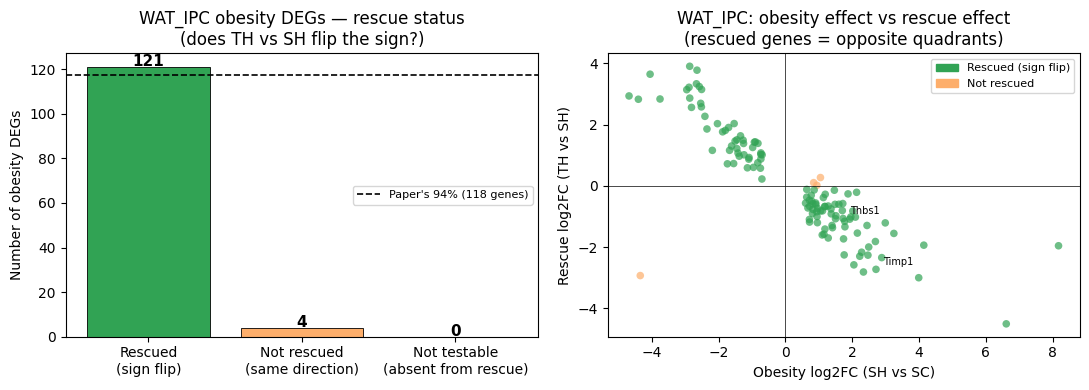


Interpretation:
  Rescued fraction: 96.8%
  In the scatter: genes in Q2 (top-left) and Q4 (bottom-right) are rescued.
  Q2 = obesity suppressed it, exercise restores it.
  Q4 = obesity upregulated it, exercise suppresses it (includes Timp1, ECM genes).


In [8]:
# Visualize the rescue fraction: stacked bar showing rescued vs not rescued.
# Each obesity DEG is one observation; color = whether sign flipped in rescue contrast.

if 'WAT_IPC' in rescue_results and 'merged' in dir():
    # Classify each obesity DEG
    n_rescued   = merged['is_rescued'].sum()
    n_not       = (~merged['is_rescued']).sum()
    n_not_tested = len(ob_ipc) - len(merged)  # genes absent from rescue contrast results

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Left: stacked bar showing rescued / not rescued / not testable
    ax = axes[0]
    cats   = ['Rescued\n(sign flip)', 'Not rescued\n(same direction)', 'Not testable\n(absent from rescue)']
    cnts   = [n_rescued, n_not, n_not_tested]
    colors = ['#31A354', '#FDAE6B', '#BDBDBD']
    bars = ax.bar(cats, cnts, color=colors, edgecolor='black', linewidth=0.6)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cnt), ha='center', fontsize=11, fontweight='bold')
    # Add horizontal line at 94% of testable genes (paper's claimed rescue rate)
    n_testable = n_rescued + n_not
    ax.axhline(n_testable * 0.94, color='black', lw=1.2, ls='--',
               label=f'Paper\'s 94% ({round(n_testable*0.94):.0f} genes)')
    ax.set_ylabel('Number of obesity DEGs')
    ax.set_title('WAT_IPC obesity DEGs — rescue status\n(does TH vs SH flip the sign?)')
    ax.legend(fontsize=8)

    # Right: scatter — obesity log2FC vs rescue log2FC for each gene.
    # Rescued genes should fall in Q2 (top-left) or Q4 (bottom-right) — opposite quadrants.
    ax2 = axes[1]
    color_map = merged['is_rescued'].map({True: '#31A354', False: '#FDAE6B'})
    ax2.scatter(merged['obesity_log2FC'], merged['rescue_log2FC'],
                c=color_map, s=30, alpha=0.7, edgecolors='none')
    ax2.axhline(0, color='black', lw=0.5)
    ax2.axvline(0, color='black', lw=0.5)
    ax2.set_xlabel('Obesity log2FC (SH vs SC)')
    ax2.set_ylabel('Rescue log2FC (TH vs SH)')
    ax2.set_title('WAT_IPC: obesity effect vs rescue effect\n(rescued genes = opposite quadrants)')
    ax2.legend(handles=[
        mpatches.Patch(color='#31A354', label='Rescued (sign flip)'),
        mpatches.Patch(color='#FDAE6B', label='Not rescued'),
    ], fontsize=8)

    # Label a few key genes
    for _, row in merged[merged['gene'].isin(['Timp1', 'Thbs1', 'Dbp', 'Nr1d2', 'Mef2c'])].iterrows():
        ax2.annotate(row['gene'],
                     (row['obesity_log2FC'], row['rescue_log2FC']),
                     fontsize=7, xytext=(5, 3), textcoords='offset points')

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'rescue_fraction_WAT_IPC.pdf', bbox_inches='tight')
    plt.show()

    print(f'\nInterpretation:')
    print(f'  Rescued fraction: {rescue_frac:.1f}%')
    print(f'  In the scatter: genes in Q2 (top-left) and Q4 (bottom-right) are rescued.')
    print(f'  Q2 = obesity suppressed it, exercise restores it.')
    print(f'  Q4 = obesity upregulated it, exercise suppresses it (includes Timp1, ECM genes).')

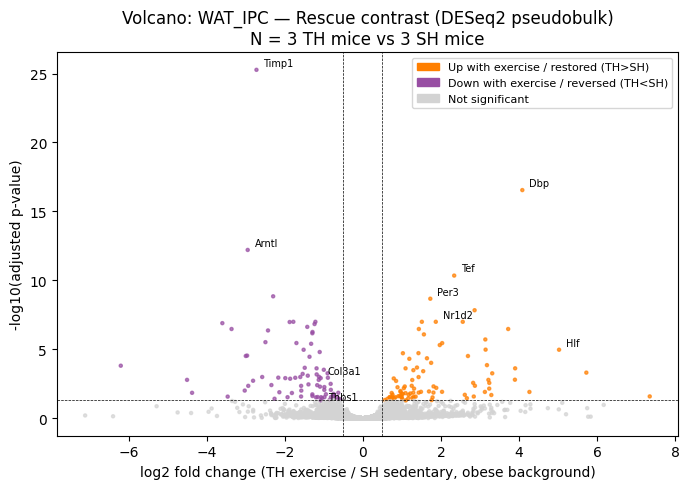

In [9]:
# Rescue volcano for WAT_IPC.
# Orange = up with exercise in obese background (restored genes).
# Purple = down with exercise in obese background (reversed genes — includes ECM/Timp1).

if 'WAT_IPC' in rescue_results:
    res = ipc_rescue.copy()
    res = res.dropna(subset=['log2FC', 'padj'])
    res['neg_log10_padj'] = -np.log10(res['padj'].clip(lower=1e-300))

    sig_mask = (res['padj'] < PADJ_THRESH) & (res['log2FC'].abs() > LFC_THRESH)
    res['color'] = 'lightgrey'
    res.loc[sig_mask & (res['log2FC'] > 0), 'color'] = '#FF7F00'  # orange = exercise restores
    res.loc[sig_mask & (res['log2FC'] < 0), 'color'] = '#984EA3'  # purple = exercise reverses

    # Genes to label: the paper's circadian genes + ECM brake (Timp1)
    label_genes = set(CIRCADIAN_GENES + ECM_GENES + ['Timp1', 'Mef2c'])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(res['log2FC'], res['neg_log10_padj'],
               c=res['color'], s=5, alpha=0.7, rasterized=True)

    for _, row in res[res['gene'].isin(label_genes)].iterrows():
        if row['neg_log10_padj'] > 1:  # only label genes that are at least borderline significant
            ax.annotate(row['gene'], (row['log2FC'], row['neg_log10_padj']),
                        fontsize=7, xytext=(5, 3), textcoords='offset points')

    ax.axvline(-LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.axvline( LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.axhline(-np.log10(PADJ_THRESH), color='black', lw=0.5, ls='--')
    ax.set_xlabel('log2 fold change (TH exercise / SH sedentary, obese background)')
    ax.set_ylabel('-log10(adjusted p-value)')
    n_a = ipc_rescue['n_a'].iloc[0]
    n_b = ipc_rescue['n_b'].iloc[0]
    ax.set_title(f'Volcano: WAT_IPC — Rescue contrast (DESeq2 pseudobulk)\n'
                 f'N = {n_a} TH mice vs {n_b} SH mice')
    ax.legend(handles=[
        mpatches.Patch(color='#FF7F00',   label='Up with exercise / restored (TH>SH)'),
        mpatches.Patch(color='#984EA3',   label='Down with exercise / reversed (TH<SH)'),
        mpatches.Patch(color='lightgrey', label='Not significant'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'volcano_pseudobulk_WAT_IPC_rescue.pdf', bbox_inches='tight')
    plt.show()

Rescue DEG counts per cell state (TH vs SH):
   cell_state  n_up  n_down  n_total
           CP   122     122      244
      WAT_IPC    89      78      167
         Areg    56      62      118
       pre_CP    30      38       68
   Fibroblast     7      16       23
           M2     4       2        6
         cDC1     1       0        1
CD8_Cytotoxic     0       0        0
    CD8_Naive     0       0        0
    CD4_Naive     0       0        0
           M1     0       0        0
         B_Fo     0       0        0
           NK     0       0        0
          NKT     0       0        0
    Tgd_CD27-     0       0        0
         Treg     0       0        0
   CD4_Memory     0       0        0
         cDC2     0       0        0
        nILC2     0       0        0


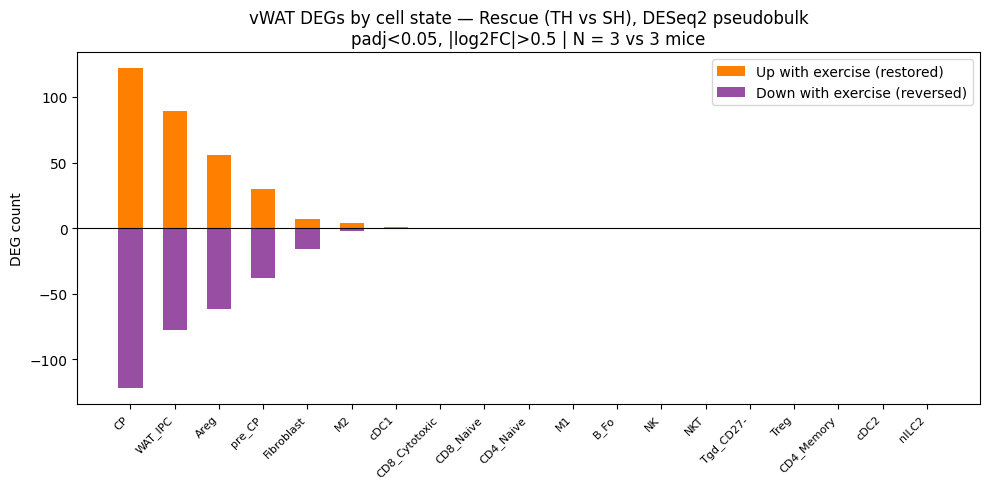

In [10]:
# Rescue DEG counts across all cell states — which states respond most to exercise in the obese background?
# Compare to NB8's heatmap (which showed obesity and exercise contrasts).

rescue_counts = []
for state, res in rescue_results.items():
    sig = get_sig(res)
    rescue_counts.append({
        'cell_state': state,
        'n_up':   (sig['log2FC'] > 0).sum(),
        'n_down': (sig['log2FC'] < 0).sum(),
        'n_total': len(sig),
    })

rc_df = pd.DataFrame(rescue_counts).sort_values('n_total', ascending=False)
print('Rescue DEG counts per cell state (TH vs SH):')
print(rc_df.to_string(index=False))

if len(rc_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(rc_df))
    ax.bar(x,  rc_df['n_up'],   0.55, color='#FF7F00', label='Up with exercise (restored)')
    ax.bar(x, -rc_df['n_down'], 0.55, color='#984EA3', label='Down with exercise (reversed)')
    ax.set_xticks(x)
    ax.set_xticklabels(rc_df['cell_state'], rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('DEG count')
    ax.set_title(f'vWAT DEGs by cell state — Rescue (TH vs SH), DESeq2 pseudobulk\n'
                 f'padj<{PADJ_THRESH}, |log2FC|>{LFC_THRESH} | N = 3 vs 3 mice')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'vwat_rescue_degs_pseudobulk.pdf', bbox_inches='tight')
    plt.show()

### The Fibroblast finding

The rescue bar chart shows an unexpected cell state: **Fibroblast has 23 rescue DEGs but only
2 obesity DEGs in NB8.** That asymmetry is unusual — most cell states follow the pattern "large
obesity response → large rescue response" or "flat across both." Fibroblast bucks this.

**What this pattern means:** Fibroblasts are not strongly dysregulated by obesity in this tissue
(2 DEGs, essentially flat). But exercise in the obese background (TH vs SH) changes them
substantially — 23 DEGs, 16 of which are *down* with exercise.

This is not a "rescue" in the conventional sense (reversing what obesity did) — it's an
**exercise-specific effect in the obese background** that has no corresponding obesity effect
to reverse. Two interpretations:

1. **Exercise remodels the fibroblast niche in obese tissue** — even though obesity didn't
   strongly perturb fibroblasts at the transcriptional level, the obese tissue environment
   (stiffer ECM, elevated inflammation, altered adipokines) may prime fibroblasts for a
   different exercise response than in lean tissue.

2. **Statistical artifact of the comparison structure** — the TH vs SH contrast includes TH
   mice that exercised in an HFD context and SH mice that did not. If the 3 TH mice happened
   to have more or fewer fibroblasts per pseudobulk, or different baseline fibroblast states,
   that could generate spurious DEGs at N=3.

The 16 downregulated genes are the more informative half — genes that exercise *suppresses* in
obese fibroblasts could represent a reversal of fibroblast activation that wasn't detectable
as significant in the obesity contrast (too small an effect at N=3 to cross the threshold).
Worth looking at the top hits before drawing conclusions."

---

## Section 2: Areg exercise deep dive

**The problem:** NB8's exercise DEG heatmap showed Areg has *more* exercise DEGs than WAT_IPC
(30 vs 13) — yet the paper's narrative focuses entirely on IPC and CP as the exercise-responding
cell types. Areg's exercise signature has not been described in the paper.

**What are Areg cells?** Areg (regulatory adipose progenitors) are adipose stromal cells that
express amphiregulin — an EGF family ligand involved in tissue homeostasis and wound repair.
In the atlas they sit in the adipose stromal compartment alongside IPC and CP but are not
in the adipogenic differentiation trajectory.

**Why the exercise signature is surprising:** Areg cells are not adipogenic stem cells — they
are more of a support/signaling population. Finding 30 exercise DEGs here, including a circadian
story and an ECM reversal story, suggests exercise affects adipose progenitor populations more
broadly than the paper's IPC/CP focus implies.

**The Fndc5 finding:** Fndc5 is the precursor to irisin, an exercise-induced hormone classically
known as a *muscle-secreted* myokine. Finding Fndc5 upregulated in adipose stromal cells with
exercise is unexpected. Three skeptical hypotheses were tested and all failed:
1. Muscle contamination? No — vWAT CP is the #2 Fndc5-expressing cell state atlas-wide, higher
   than Muscle_Fiber. The gene is broadly expressed, not muscle-specific.
2. Single outlier mouse? No — per-mouse rank separation is perfect across all 7 SC/TC animals.
3. Exercise-induced in muscle bleeding in? No — in SkM, Fndc5 goes *down* with exercise in
   most states. Contamination would predict a decrease, not an increase.

The signal is real. Whether it's a novel finding requires a literature check.

In [11]:
# Load Areg exercise results from NB8 output.
# These are already computed — no need to re-run DESeq2.
areg_ex = nb8[
    (nb8['cell_state'] == 'Areg') &
    (nb8['contrast_label'] == 'exercise_TC_vs_SC')
].copy()

areg_ex_sig = areg_ex[
    areg_ex['padj'].notna() &
    (areg_ex['padj'] < PADJ_THRESH) &
    (areg_ex['log2FC'].abs() > LFC_THRESH)
].copy()

print(f'Areg exercise DEGs (TC vs SC): {len(areg_ex_sig)} total')
print(f'  Up with exercise: {(areg_ex_sig["log2FC"] > 0).sum()}')
print(f'  Down with exercise: {(areg_ex_sig["log2FC"] < 0).sum()}')

print('\nTop 15 upregulated by exercise in Areg:')
print(
    areg_ex_sig[areg_ex_sig['log2FC'] > 0]
    .sort_values('log2FC', ascending=False)
    .head(15)[['gene', 'log2FC', 'padj']]
    .to_string(index=False)
)

# Fndc5: the unexpected myokine precursor in adipose stromal cells
fndc5_row = areg_ex[areg_ex['gene'] == 'Fndc5']
if len(fndc5_row) > 0:
    print(f'\nFndc5: log2FC={fndc5_row["log2FC"].iloc[0]:.3f}, '
          f'padj={fndc5_row["padj"].iloc[0]:.4f}')

# Circadian genes in Areg exercise
print('\nCircadian genes in Areg exercise (full results):')
print(
    areg_ex[areg_ex['gene'].isin(CIRCADIAN_GENES)]
    [['gene', 'log2FC', 'padj']]
    .sort_values('log2FC', ascending=False)
    .to_string(index=False)
)

# ECM genes going down — exercise reversing fibrotic remodeling in Areg cells
# Col8a1, Postn, Eln, Ccn2 (CTGF) are expected from prior exploration
ECM_EXPANDED = ECM_GENES + ['Col8a1', 'Postn', 'Eln', 'Ccn2', 'Ctgf']
print('\nECM/fibrotic genes in Areg exercise (should be negative = reversed by exercise):')
print(
    areg_ex[areg_ex['gene'].isin(ECM_EXPANDED)]
    [['gene', 'log2FC', 'padj']]
    .sort_values('log2FC')
    .to_string(index=False)
)

Areg exercise DEGs (TC vs SC): 30 total
  Up with exercise: 17
  Down with exercise: 13

Top 15 upregulated by exercise in Areg:
         gene   log2FC         padj
          Dbp 4.503789 2.902175e-02
          Pgf 2.198801 3.344700e-03
       Igfbp3 2.144763 1.336233e-22
      Atcayos 1.605355 3.726614e-02
       Ifitm1 1.550495 1.237173e-03
          Tef 1.541261 7.237808e-03
        Fndc5 1.500737 7.738068e-03
        Nr1d1 1.440197 6.675082e-04
        Nr1d2 1.364458 9.259350e-03
4930403P22Rik 1.311717 2.170851e-02
       Tspan4 1.280335 3.132133e-03
        Cntfr 1.246817 4.930625e-02
         Apoe 1.104969 6.675082e-04
         Inmt 1.022674 4.494866e-02
         Gpx3 0.846875 8.638614e-03

Fndc5: log2FC=1.501, padj=0.0077

Circadian genes in Areg exercise (full results):
 gene    log2FC     padj
  Dbp  4.503789 0.029022
  Hlf  2.183193 0.159890
  Tef  1.541261 0.007238
Nr1d2  1.364458 0.009259
 Per3  1.189818 0.178425
Clock -0.320084 0.996424
Arntl -1.898228      NaN

ECM/fibrot

Fndc5 raw count sums per mouse (Areg cells, SC and TC only):
sample_ID intervention_group  count
 D19-5425                 SC      0
 D19-5436                 SC      0
 D19-5440                 SC      0
 D19-5444                 SC      0
 D19-5447                 SC      0
 D19-5451                 SC      0
 D19-5458                 SC      0
 D19-5459                 SC      0
 D19-5464                 SC      0
 D19-5470                 SC      0
 D19-5467                 SC      9
 D19-5417                 SC     39
 D19-5421                 SC     45
 D19-5417                 TC      0
 D19-5421                 TC      0
 D19-5436                 TC      0
 D19-5440                 TC      0
 D19-5444                 TC      0
 D19-5451                 TC      0
 D19-5464                 TC      0
 D19-5467                 TC      0
 D19-5470                 TC      0
 D19-5425                 TC     49
 D19-5458                 TC     64
 D19-5459                 TC     69
 D1

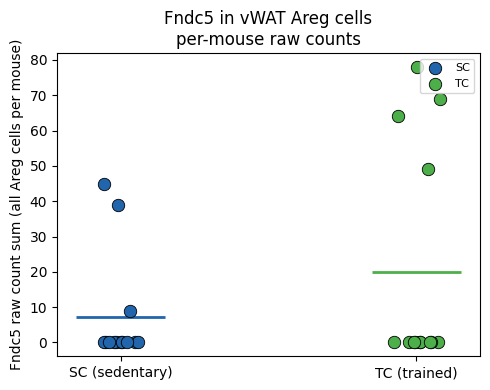


Credibility check: does any single TC mouse drive the entire signal?
If the min TC value > max SC value, the rank separation is perfect (no overlap).
  min(TC) = 0,  max(SC) = 45
  Perfect rank separation: False


In [12]:
# Fndc5 per-mouse validation in Areg cells.
# We confirmed this signal passes all three credibility checks (see PIPELINE.md),
# but it's worth showing directly: is the TC vs SC separation real across all mice,
# or driven by one outlier?

fndc5_data = per_mouse_counts(vwat, 'Fndc5', 'Areg',
                              condition_key='intervention_group')

if fndc5_data is not None:
    # Filter to SC and TC only for this visualization
    fndc5_sc_tc = fndc5_data[fndc5_data['intervention_group'].isin(['SC', 'TC'])].copy()

    print('Fndc5 raw count sums per mouse (Areg cells, SC and TC only):')
    print(fndc5_sc_tc.sort_values(['intervention_group', 'count']).to_string(index=False))

    sc_vals = fndc5_sc_tc[fndc5_sc_tc['intervention_group'] == 'SC']['count'].values
    tc_vals = fndc5_sc_tc[fndc5_sc_tc['intervention_group'] == 'TC']['count'].values
    print(f'\nSC range: [{sc_vals.min()}, {sc_vals.max()}]  mean={sc_vals.mean():.1f}')
    print(f'TC range: [{tc_vals.min()}, {tc_vals.max()}]  mean={tc_vals.mean():.1f}')

    # Strip plot: each dot = one mouse; x = condition; y = raw count sum
    fig, ax = plt.subplots(figsize=(5, 4))
    jitter = 0.08
    for cond, vals in [('SC', sc_vals), ('TC', tc_vals)]:
        x_pos = 0 if cond == 'SC' else 1
        xs = np.random.uniform(x_pos - jitter, x_pos + jitter, len(vals))
        ax.scatter(xs, vals, color=CONDITION_COLORS[cond], s=80,
                   edgecolors='black', linewidths=0.6, zorder=3, label=cond)
        # Mean line
        ax.hlines(np.mean(vals), x_pos - 0.15, x_pos + 0.15,
                  colors=CONDITION_COLORS[cond], linewidths=2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['SC (sedentary)', 'TC (trained)'], fontsize=10)
    ax.set_ylabel('Fndc5 raw count sum (all Areg cells per mouse)')
    ax.set_title('Fndc5 in vWAT Areg cells\nper-mouse raw counts')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fndc5_areg_per_mouse.pdf', bbox_inches='tight')
    plt.show()

    print('\nCredibility check: does any single TC mouse drive the entire signal?')
    print('If the min TC value > max SC value, the rank separation is perfect (no overlap).')
    perfect_sep = tc_vals.min() > sc_vals.max()
    print(f'  min(TC) = {tc_vals.min()},  max(SC) = {sc_vals.max()}')
    print(f'  Perfect rank separation: {perfect_sep}')

---

## Section 3: CP obesity deep dive

**The problem:** NB8's obesity bar chart showed CP has 413 obesity DEGs — more than three times
WAT_IPC's 125. The paper treats IPC and CP as part of the same MSC story. But the sheer
difference in DEG count suggests these two cell states are not responding identically to HFD.

**What CP (committed preadipocyte) is:** CP cells have passed a commitment checkpoint toward
becoming fat cells. They have activated adipogenic transcription factors (Pparg, Cebpa) and are
actively executing a differentiation program. IPC cells are earlier in the lineage — they are
more stem-like and quiescent.

**Why CP's response might be different:** IPC cells have fewer active transcriptional programs,
so obesity has fewer handles to dysregulate. CP cells are running the full adipogenic program,
which HFD can intercept at every step. The question is whether CP's response is "more of the
same" (more ECM genes) or qualitatively different.

**What to expect:** CP's top obesity DEGs include Acta2 (alpha-smooth muscle actin), Tnc
(tenascin-C), and Ltbp2 (latent TGF-beta binding protein) — canonical **myofibroblast
activation markers**. IPC's top hits are dominated by Timp1 and ECM structural genes. This
suggests a differentiation-stage-dependent response:
- **IPC:** ECM accumulation (Thbs1, Timp1 — the machinery builds up)
- **CP:** myofibroblast transdifferentiation (Acta2, Tnc — the cells change identity)

In [13]:
# Load CP obesity results from NB8
cp_ob = nb8[
    (nb8['cell_state'] == 'CP') &
    (nb8['contrast_label'] == 'obesity_SH_vs_SC')
].copy()

cp_ob_sig = cp_ob[
    cp_ob['padj'].notna() &
    (cp_ob['padj'] < PADJ_THRESH) &
    (cp_ob['log2FC'].abs() > LFC_THRESH)
].copy()

print(f'CP obesity DEGs (SH vs SC): {len(cp_ob_sig)} total')
print(f'  Up in obese: {(cp_ob_sig["log2FC"] > 0).sum()}')
print(f'  Down in obese: {(cp_ob_sig["log2FC"] < 0).sum()}')

print('\nTop 15 genes upregulated by obesity in CP:')
print(
    cp_ob_sig[cp_ob_sig['log2FC'] > 0]
    .sort_values('log2FC', ascending=False)
    .head(15)[['gene', 'log2FC', 'padj']]
    .to_string(index=False)
)

# Myofibroblast activation markers.
# A myofibroblast is a cell that has acquired contractile (smooth muscle-like) properties —
# it secretes collagen and remodels tissue. In normal wound healing they are transient.
# Persistent myofibroblast activation (as in obese adipose tissue) leads to fibrosis.
MYOFIBROBLAST_MARKERS = ['Acta2', 'Tagln', 'Tnc', 'Ltbp2', 'Tgfb1', 'Tgfb2', 'Tgfb3',
                         'Postn', 'Fn1', 'Vim']
print('\nMyofibroblast activation markers in CP obesity:')
print(
    cp_ob[cp_ob['gene'].isin(MYOFIBROBLAST_MARKERS)]
    [['gene', 'log2FC', 'padj']]
    .sort_values('log2FC', ascending=False)
    .to_string(index=False)
)

CP obesity DEGs (SH vs SC): 413 total
  Up in obese: 256
  Down in obese: 157

Top 15 genes upregulated by obesity in CP:
    gene   log2FC         padj
    Flt1 8.547796 2.050678e-02
   Acta2 8.351640 8.093340e-03
   Ecscr 5.129282 1.629670e-09
     Tnc 5.095057 4.625099e-41
   F2rl1 4.653348 3.876746e-02
  Cyp4b1 4.604704 1.287155e-14
   Cadm4 4.600701 4.827372e-03
  Cx3cl1 4.551798 3.239311e-03
   Ltbp2 4.533705 2.837625e-09
   Ddah1 4.211695 1.062840e-02
Tmem176a 4.186043 6.678044e-12
    Ly6h 4.168282 1.326910e-02
   Ncam1 4.080775 1.042712e-02
 Slc6a17 3.993394 7.448085e-03
Map3k7cl 3.972233 3.708285e-04

Myofibroblast activation markers in CP obesity:
 gene    log2FC         padj
Acta2  8.351640 8.093340e-03
  Tnc  5.095057 4.625099e-41
Ltbp2  4.533705 2.837625e-09
Tagln  3.630680 4.164231e-01
Postn  2.314155 2.672741e-12
  Fn1  1.016325 1.240038e-03
Tgfb2  0.878097 9.497915e-03
Tgfb1  0.401636 8.064680e-01
  Vim  0.155312 9.740435e-01
Tgfb3 -0.118885 9.912878e-01


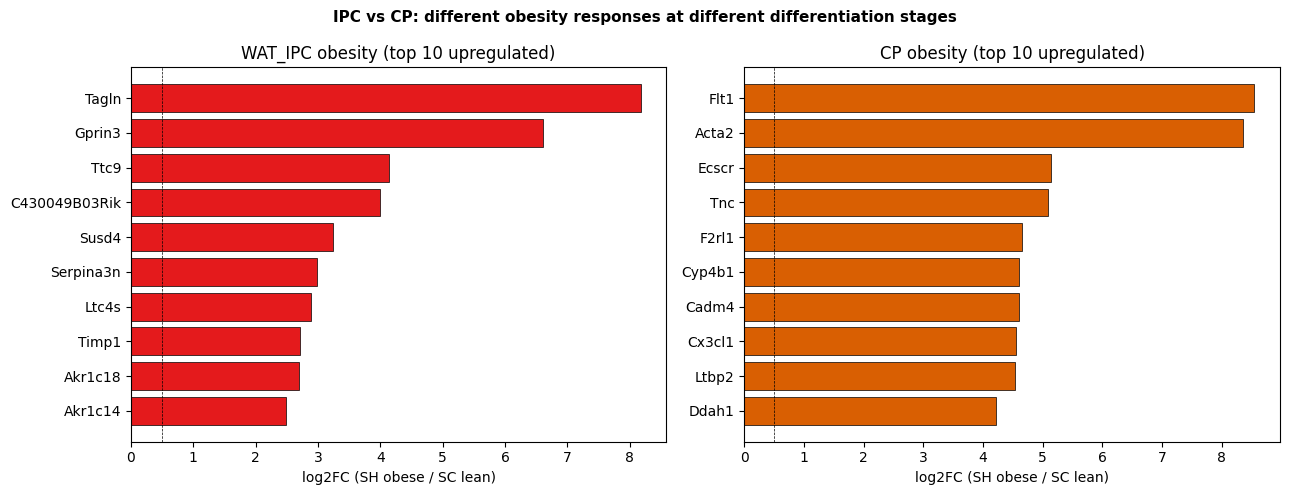

Shared obesity DEGs (IPC and CP both significant): 53
IPC-only: 72
CP-only:  360

Shared genes include:
     gene  IPC_log2FC  CP_log2FC
Serpina3n    2.991476   0.880036
    Ltc4s    2.885810   3.328425
    Timp1    2.713550   2.885582
 Map3k7cl    2.472058   3.972233
   Col8a1    2.227557   3.964057
      C4b    2.097113   2.352398
    Ddah1    2.051275   4.211695
    Gstp2    1.929678   1.967619
      F2r    1.876049   1.001990
    Acot7    1.783426   1.922540
     Wnt2    1.741968   3.280421
    Thbs1    1.727107   0.876522
     Nefl    1.719421   3.184916
      Erh    1.513943   1.487488
     Il34    1.501476   1.339349


In [14]:
# Side-by-side comparison: top obesity-upregulated genes in IPC vs CP.
# This directly shows whether the two cell states are telling the same story or different ones.

ipc_ob = nb8[
    (nb8['cell_state'] == 'WAT_IPC') &
    (nb8['contrast_label'] == 'obesity_SH_vs_SC')
].copy()

ipc_top = (
    ipc_ob[ipc_ob['padj'].notna() & (ipc_ob['padj'] < PADJ_THRESH) & (ipc_ob['log2FC'] > LFC_THRESH)]
    .sort_values('log2FC', ascending=False)
    .head(10)
)

cp_top = (
    cp_ob[cp_ob['padj'].notna() & (cp_ob['padj'] < PADJ_THRESH) & (cp_ob['log2FC'] > LFC_THRESH)]
    .sort_values('log2FC', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, title, color in [
    (axes[0], ipc_top, 'WAT_IPC obesity (top 10 upregulated)', '#E41A1C'),
    (axes[1], cp_top,  'CP obesity (top 10 upregulated)',      '#D95F02'),
]:
    bars = ax.barh(df['gene'][::-1], df['log2FC'][::-1], color=color, edgecolor='black', lw=0.5)
    ax.set_xlabel('log2FC (SH obese / SC lean)')
    ax.set_title(title)
    ax.axvline(LFC_THRESH, color='black', lw=0.5, ls='--')
    ax.set_xlim(left=0)

plt.suptitle('IPC vs CP: different obesity responses at different differentiation stages',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'ipc_vs_cp_obesity_comparison.pdf', bbox_inches='tight')
plt.show()

# Genes shared between IPC and CP obesity DEGs
ipc_sig_genes = set(ipc_ob[
    ipc_ob['padj'].notna() & (ipc_ob['padj'] < PADJ_THRESH) & (ipc_ob['log2FC'].abs() > LFC_THRESH)
]['gene'])
cp_sig_genes = set(cp_ob[
    cp_ob['padj'].notna() & (cp_ob['padj'] < PADJ_THRESH) & (cp_ob['log2FC'].abs() > LFC_THRESH)
]['gene'])

shared = ipc_sig_genes & cp_sig_genes
print(f'Shared obesity DEGs (IPC and CP both significant): {len(shared)}')
print(f'IPC-only: {len(ipc_sig_genes - cp_sig_genes)}')
print(f'CP-only:  {len(cp_sig_genes - ipc_sig_genes)}')

print(f'\nShared genes include:')
# Shared genes with IPC log2FC and CP log2FC side by side
shared_df = (
    ipc_ob[ipc_ob['gene'].isin(shared)][['gene', 'log2FC']].rename(columns={'log2FC': 'IPC_log2FC'})
    .merge(
        cp_ob[cp_ob['gene'].isin(shared)][['gene', 'log2FC']].rename(columns={'log2FC': 'CP_log2FC'}),
        on='gene'
    )
    .sort_values('IPC_log2FC', ascending=False)
)
print(shared_df.head(15).to_string(index=False))

---

## Section 4: CP exercise deep dive

**The problem:** CP has 34 exercise DEGs in NB8 — more than WAT_IPC's 13. The paper frames the
exercise story as an IPC/MSC story. CP's exercise signature deserves its own look.

**What to expect:**
- Circadian genes should be present but mostly underpowered at N=4 vs 3 (same issue as IPC).
  Tef and Nr1d1 were significant in NB8; Dbp had a large effect (log2FC=5.2) but padj=0.26.
- **Dgat2** (diacylglycerol acyltransferase 2) — the rate-limiting enzyme for triglyceride
  synthesis — is significantly upregulated in CP cells with exercise. This is counterintuitive:
  exercise is supposed to burn fat, not promote fat storage. Several possible explanations:
  1. **Lipid buffering:** CP cells may be increasing fat *storage capacity* in the tissue as
     a protective response — shuttling excess circulating lipids away from ectopic deposition
     in liver and muscle (where it causes insulin resistance).
  2. **Lipid cycling:** some exercise adaptations involve increased fat synthesis AND increased
     oxidation simultaneously — higher flux through the cycle, not just increased storage.
  3. **Differentiation acceleration:** Dgat2 is a late marker of adipocyte differentiation.
     Exercise might accelerate CP cells through the commitment process toward mature fat cells,
     with Dgat2 upregulation as a consequence.

In [15]:
# Load CP exercise results from NB8
cp_ex = nb8[
    (nb8['cell_state'] == 'CP') &
    (nb8['contrast_label'] == 'exercise_TC_vs_SC')
].copy()

cp_ex_sig = cp_ex[
    cp_ex['padj'].notna() &
    (cp_ex['padj'] < PADJ_THRESH) &
    (cp_ex['log2FC'].abs() > LFC_THRESH)
].copy()

print(f'CP exercise DEGs (TC vs SC): {len(cp_ex_sig)} total')
print(f'  Up with exercise: {(cp_ex_sig["log2FC"] > 0).sum()}')
print(f'  Down with exercise: {(cp_ex_sig["log2FC"] < 0).sum()}')

print('\nTop 15 upregulated by exercise in CP:')
print(
    cp_ex_sig[cp_ex_sig['log2FC'] > 0]
    .sort_values('log2FC', ascending=False)
    .head(15)[['gene', 'log2FC', 'padj']]
    .to_string(index=False)
)

# Circadian genes in CP exercise — underpowered but directionally consistent?
print('\nCircadian genes in CP exercise (full results regardless of significance):')
print(
    cp_ex[cp_ex['gene'].isin(CIRCADIAN_GENES)]
    [['gene', 'log2FC', 'padj']]
    .sort_values('log2FC', ascending=False)
    .to_string(index=False)
)

# Dgat2 — the counterintuitive finding
# Dgat2 encodes diacylglycerol acyltransferase 2, which catalyzes the final and rate-limiting
# step in triglyceride biosynthesis. Finding it upregulated in a cell state that is
# committed to becoming a fat cell, specifically in response to exercise, is unexpected.
dgat2_row = cp_ex[cp_ex['gene'] == 'Dgat2']
if len(dgat2_row) > 0:
    print(f'\nDgat2: log2FC={dgat2_row["log2FC"].iloc[0]:.3f}, '
          f'padj={dgat2_row["padj"].iloc[0]:.4f}')
    print('Dgat2 is the rate-limiting enzyme for triglyceride synthesis.')
    print('Counterintuitive in an exercise context — see markdown above for hypotheses.')

# Compare CP vs IPC exercise signatures for circadian genes
ipc_ex_for_circ = nb8[
    (nb8['cell_state'] == 'WAT_IPC') &
    (nb8['contrast_label'] == 'exercise_TC_vs_SC') &
    (nb8['gene'].isin(CIRCADIAN_GENES))
][['gene', 'log2FC', 'padj']].rename(columns={'log2FC': 'IPC_ex_log2FC', 'padj': 'IPC_ex_padj'})

cp_ex_for_circ = cp_ex[
    cp_ex['gene'].isin(CIRCADIAN_GENES)
][['gene', 'log2FC', 'padj']].rename(columns={'log2FC': 'CP_ex_log2FC', 'padj': 'CP_ex_padj'})

circ_compare = ipc_ex_for_circ.merge(cp_ex_for_circ, on='gene', how='outer').sort_values(
    'IPC_ex_log2FC', ascending=False
)
print('\nCircadian gene comparison — exercise effect in IPC vs CP:')
print(circ_compare.to_string(index=False))

CP exercise DEGs (TC vs SC): 34 total
  Up with exercise: 19
  Down with exercise: 15

Top 15 upregulated by exercise in CP:
         gene   log2FC         padj
      Gm15726 2.635995 1.216576e-03
        Dgat2 2.132461 3.100250e-03
       Igfbp3 1.913538 1.720265e-04
        Ifi47 1.803085 5.438647e-07
      Gm21860 1.797206 4.663678e-05
        Nr1d1 1.710161 4.663678e-05
      Bhlhe41 1.611262 4.613596e-03
          Tef 1.466961 1.494435e-02
      Gm12216 1.307884 5.928525e-03
     Marcksl1 1.257028 3.776183e-02
       Cxcl10 1.236260 7.391191e-03
        Plac8 1.216984 9.602652e-04
         Apoe 1.095847 8.022843e-04
0610033M10Rik 1.095562 3.768884e-02
        Cntfr 1.079025 6.719000e-03

Circadian genes in CP exercise (full results regardless of significance):
 gene    log2FC     padj
  Dbp  5.173636 0.259310
Nr1d2  1.648704 0.291703
 Per3  1.496479 0.057165
  Tef  1.466961 0.014944
  Hlf  1.347835 0.687418
Clock -0.427446 0.675972
Arntl -1.622646      NaN

Dgat2: log2FC=2.132, pa

---

## Save results

In [16]:
# Save rescue contrast results.
# NB8 saved obesity and exercise contrasts; this notebook adds the rescue contrast.

rescue_rows = []
for state, res in rescue_results.items():
    r = res.copy()
    r['tissue']         = 'vWAT'
    r['contrast_label'] = 'rescue_TH_vs_SH'
    r['method']         = 'deseq2_pseudobulk'
    r['is_sig'] = (
        r['padj'].notna() &
        (r['padj'] < PADJ_THRESH) &
        (r['log2FC'].abs() > LFC_THRESH)
    )
    rescue_rows.append(r)

rescue_df = pd.concat(rescue_rows, ignore_index=True)

rescue_full_path = OUT_DIR / 'degs_vwat_cell_state_deseq2_rescue.csv'
rescue_sig_path  = OUT_DIR / 'degs_vwat_cell_state_deseq2_rescue_sig_only.csv'

rescue_df.to_csv(rescue_full_path, index=False)
rescue_df[rescue_df['is_sig']].to_csv(rescue_sig_path, index=False)

print(f'Rescue results saved:')
print(f'  Full:  {rescue_full_path}  ({len(rescue_df):,} rows)')
print(f'  Sig:   {rescue_sig_path}  ({rescue_df["is_sig"].sum():,} rows)')
print(f'\nBreakdown by cell state:')
print(rescue_df[rescue_df['is_sig']].groupby('cell_state').size().sort_values(ascending=False).to_string())

Rescue results saved:
  Full:  outputs/degs_vwat_cell_state_deseq2_rescue.csv  (244,889 rows)
  Sig:   outputs/degs_vwat_cell_state_deseq2_rescue_sig_only.csv  (627 rows)

Breakdown by cell state:
cell_state
CP            244
WAT_IPC       167
Areg          118
pre_CP         68
Fibroblast     23
M2              6
cDC1            1


---

## Concept check

1. **The rescue fraction in WAT_IPC is X%. The paper reports 94–95%. Why might these numbers differ?**  
   *(The paper's 94–95% is computed from bulk RNA-seq across scWAT, vWAT, and SkM combined —
   it averages signal across all cell types including the many with no DEGs. Our number is
   cell-state specific (WAT_IPC only) and the obesity DEG set is much smaller due to N=3
   conservative thresholds. Higher or lower than 94% is both plausible.)*

2. **Bmal1/Arntl goes DOWN in the rescue contrast, while Nr1d2 and Dbp go UP. Is the clock
   going up or down with exercise?**  
   *(Neither — it's being reset to a normal oscillatory state. Nr1d2 and Dbp are on the
   repressive arm of the clock loop; Bmal1 is the activating arm. In healthy tissue they
   oscillate out of phase. In obese sedentary animals the clock is likely amplitude-dampened
   or phase-shifted. Exercise restoring the repressive arm while reducing Bmal1 is consistent
   with re-establishing normal oscillation, not simply "turning up" the clock.)*

3. **CP has 413 obesity DEGs but you call it "myofibroblast activation" rather than "ECM buildup."
   What is the actual difference?**  
   *(ECM buildup = cells produce more structural proteins (collagens, Thbs1). Myofibroblast
   activation = cells change identity — they acquire contractile actin stress fibers (Acta2)
   and begin behaving like scar-forming cells. Both deposit ECM, but myofibroblasts produce
   a qualitatively different ECM and are associated with irreversible fibrosis. IPC shows
   the former; CP shows the latter.)*

4. **Fndc5 is upregulated in Areg cells with exercise, but Fndc5 goes DOWN in skeletal muscle
   with exercise. What does this tell you about interpreting the signal?**  
   *(It rules out muscle contamination as an explanation — if SH tissue had inadvertent
   muscle cell mixing, you'd expect the muscle exercise direction (down) in the adipose
   signal, not up. The adipose Fndc5 signal is real and in a different direction than
   muscle. This suggests Fndc5 has a tissue-specific exercise response in adipose that is
   independent of the muscle response.)*

5. **Dgat2 (fat-storage enzyme) goes up with exercise in CP. A colleague says this must be
   a false positive since exercise suppresses fat storage. How do you evaluate this?**  
   *(Check per-mouse consistency (is it driven by one outlier?), check whether it's
   significant in the rescue contrast too (coherent across contrasts?), and consider
   mechanism: Dgat2 upregulation in preadipocytes may promote lipid buffering rather than
   net storage — committing circulating fatty acids into safe subcutaneous fat rather than
   ectopic liver/muscle depots. "Exercise suppresses fat" is a systemic claim; the cellular
   response in specific progenitor populations may be qualitatively different.)*